<a href="https://colab.research.google.com/github/Minh-Khuong/Bai-tap-Ai-tuan-1-Vu-Minh-Khuong-31251020110/blob/Bai-Tap-AI-Tuan-1/Bai%20tap%20AI-Tuan%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#23.1
import folium
from geopy.geocoders import Nominatim
geolocator = Nominatim(user_agent="bai_23_1", timeout=10)
truong_hoc = geolocator.geocode("Đại học Kinh tế, TP.HCM")
center_coords = (truong_hoc.latitude, truong_hoc.longitude)
m = folium.Map(location=center_coords, zoom_start=15)
folium.Marker(center_coords, popup="UEH", icon=folium.Icon(color="red")).add_to(m)
dia_diem_lan_can = ["Bệnh viện Từ Dũ", "Chợ Bến Thành", "Dinh Độc Lập", "Nhà văn hóa Thanh Niên"]
for ten in dia_diem_lan_can:
    loc = geolocator.geocode(ten + ", TP.HCM")
    if loc:
        folium.Marker((loc.latitude, loc.longitude), popup=ten, icon=folium.Icon(color="blue")).add_to(m)
display(m)

In [4]:
#23.2
import folium
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

geolocator = Nominatim(user_agent="bai_23_2", timeout=10)
diem_goc = geolocator.geocode("Đại học Kinh tế, TP.HCM")
toado_goc = (diem_goc.latitude, diem_goc.longitude)

m = folium.Map(location=toado_goc, zoom_start=13)
folium.Marker(toado_goc, popup="Điểm xuất phát (UEH)", icon=folium.Icon(color="red")).add_to(m)
danh_sach_den = ["Landmark 81", "Sân bay Tân Sơn Nhất", "Thảo Cầm Viên"]

for ten in danh_sach_den:
    loc = geolocator.geocode(ten + ", TP.HCM")
    if loc:
        toado_den = (loc.latitude, loc.longitude)
        khoang_cach = geodesic(toado_goc, toado_den).km
        folium.Marker(toado_den, popup=f"{ten} ({khoang_cach:.2f} km)").add_to(m)
        folium.PolyLine([toado_goc, toado_den], color="green", weight=3).add_to(m)

display(m)

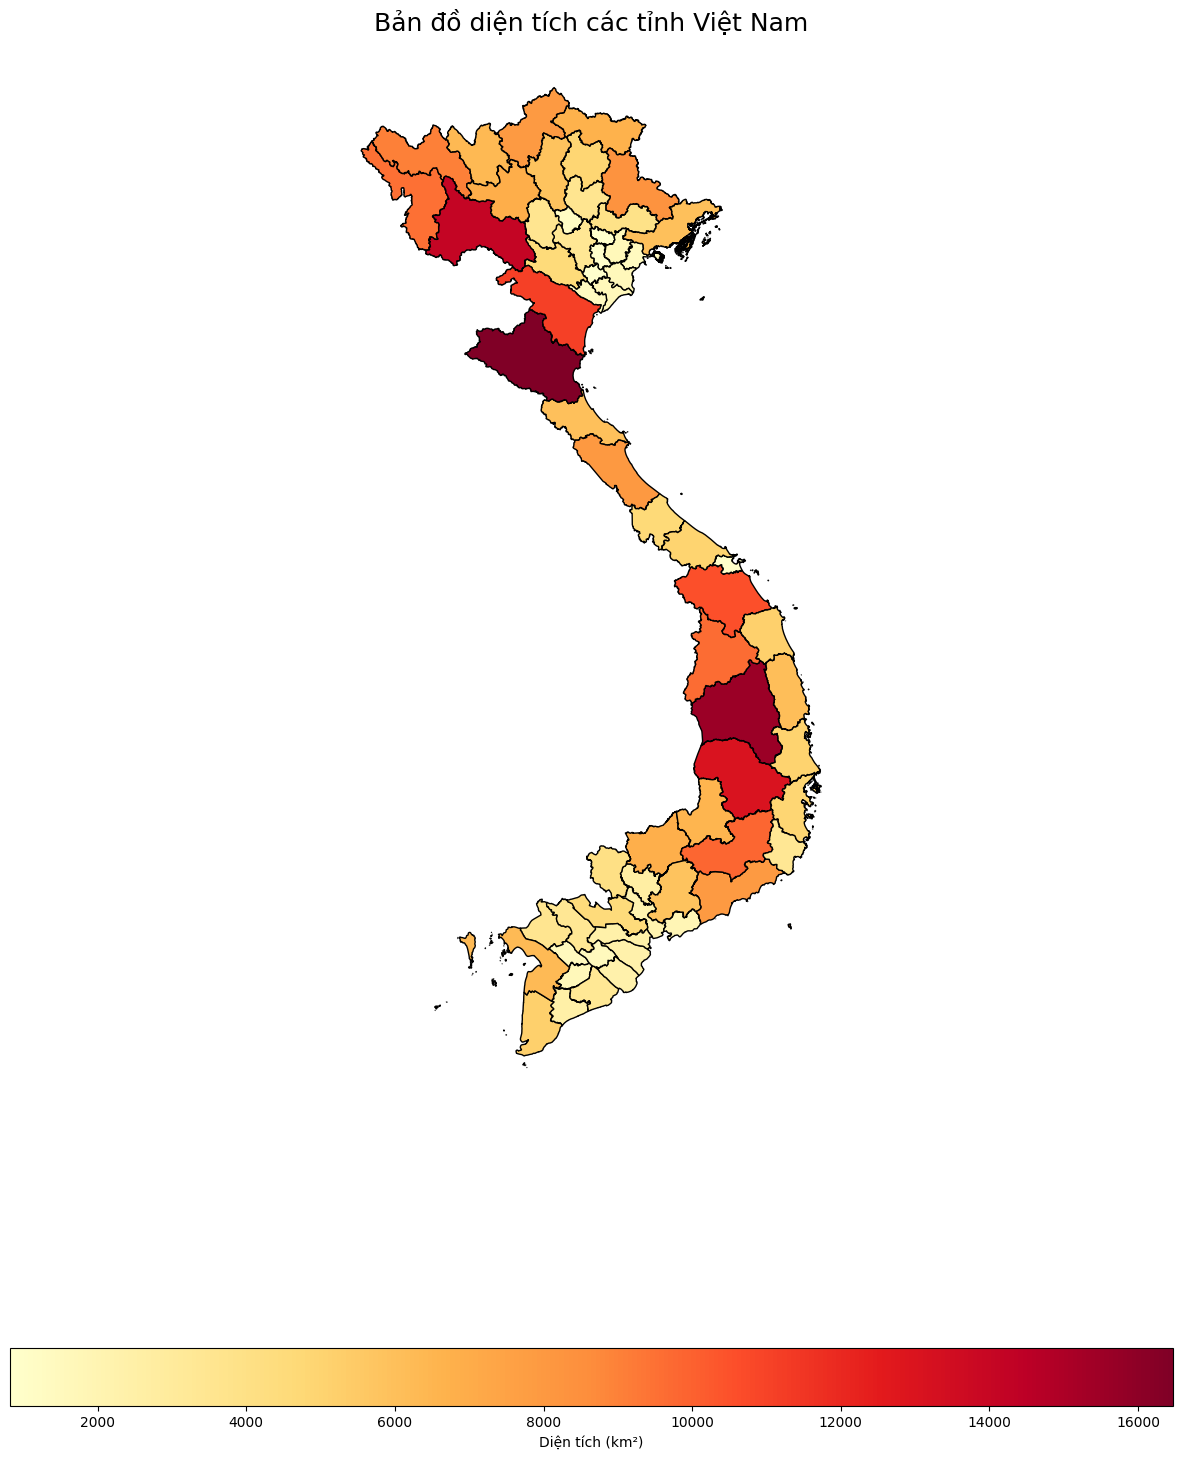

In [10]:
# 23.4
import geopandas as gpd
import matplotlib.pyplot as plt
vietnam = gpd.read_file("/content/gadm41_VNM_1.json")
vietnam = vietnam.to_crs(epsg=3405)
vietnam['dien_tich_km2'] = vietnam['geometry'].area / 10**6
fig, ax = plt.subplots(figsize=(15, 20))
vietnam.plot(
    column='dien_tich_km2',
    ax=ax,
    cmap='YlOrRd',
    edgecolor='black',
    legend=True,
    legend_kwds={
        'label': "Diện tích (km²)",
        'orientation': "horizontal"
    }
)
plt.title("Bản đồ diện tích các tỉnh Việt Nam", fontsize=18)
ax.set_axis_off()
plt.show()

In [6]:
# 23.5
import folium
from geopy.geocoders import Nominatim
geolocator = Nominatim(user_agent="bai_23_5")
loc = geolocator.geocode("Đại học Kinh tế, TP.HCM")
toa_do_kho = [loc.latitude, loc.longitude]
m = folium.Map(location=toa_do_kho, zoom_start=13)
folium.Marker(toa_do_kho, popup="Đại học Kinh tế (UEH)", icon=folium.Icon(color="red")).add_to(m)
folium.Circle(toa_do_kho, radius=1000, color="green", fill=True, tooltip="Giao siêu tốc (1km)").add_to(m)
folium.Circle(toa_do_kho, radius=3000, color="blue", fill=False, tooltip="Giao tiêu chuẩn (3km)").add_to(m)
folium.Circle(toa_do_kho, radius=5000, color="orange", fill=False, tooltip="Giao chậm (5km)").add_to(m)
display(m)